In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys

sys.path.append('..')

from src.models import PollutionSVModel, PollutionOptionPricer, HestonPricer, HestonPollutionPricer

In [2]:
from pathlib import Path

ROOT = Path('..').resolve()

In [3]:
df = pd.read_csv(ROOT / 'data' / 'csi300_pollution_s2_df.csv', index_col='Date', parse_dates=True)


  PollutionSVModel — Kalman Filter + Milstein
                            Value          Interpretation
Parameter                                                
α (mean-reversion)       2.661214    Half-life: 65.6 days
θ (long-run vol)         0.100033  Unconditional vol: 0.1
β (vol of vol)           0.537025     Diffusion intensity
δ (pollution effect)     0.002175                  (>0 ✓)
Log-likelihood        6932.807300                        



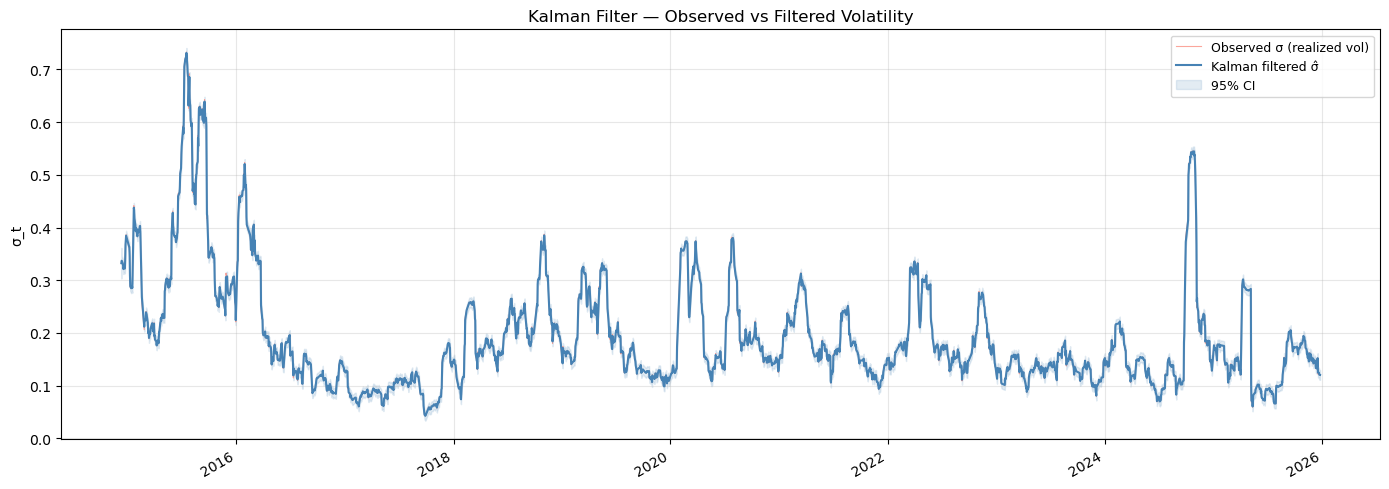

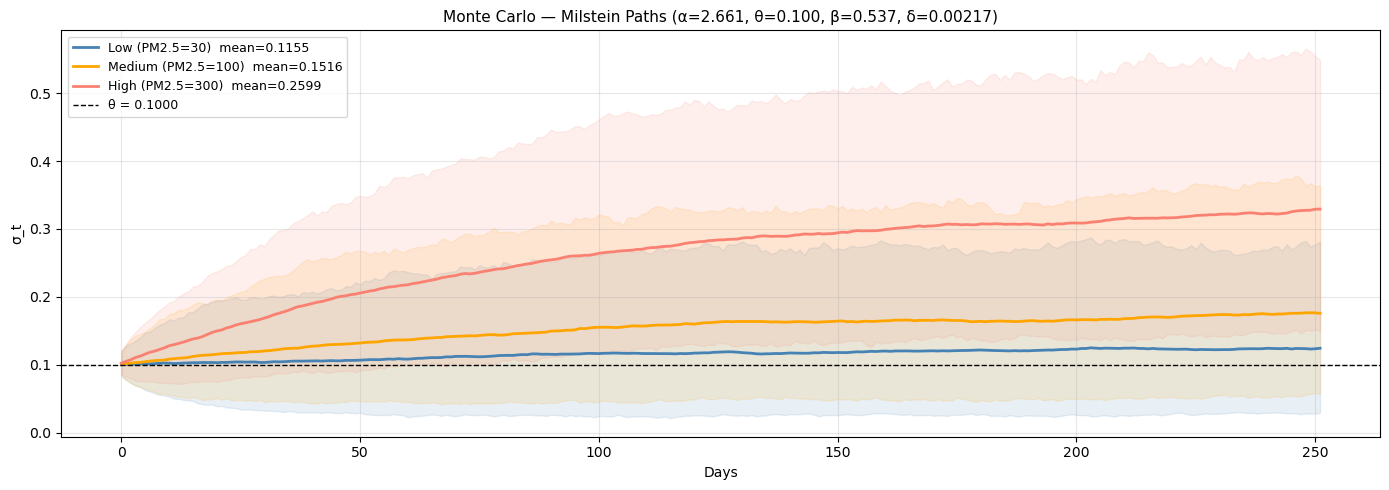

          Scenario  PM2.5  Mean σ   P5 σ  P95 σ
    Low (PM2.5=30)     30  0.1155 0.0291 0.2498
Medium (PM2.5=100)    100  0.1516 0.0492 0.3036
  High (PM2.5=300)    300  0.2599 0.1189 0.4404


In [4]:
sv = PollutionSVModel(
    sigma     = df['realized_vol'],
    pollution = df['pm25'],
    dt        = 1/252
)

sv.fit(delta_init=0.0029)  # initialize δ with the GARCH-X estimate 
sv.summary()

sv.plot_filtered()

sv.simulate_paths({
    'Low (PM2.5=30)':     30,
    'Medium (PM2.5=100)': 100,
    'High (PM2.5=300)':   300,
})

Estimated ρ : -0.0971
    Strike K Scenario  PM2.5      Price  Std Err
0    3958.65      Low     30   996.9029  16.6902
1    3958.65   Medium    100  1072.0567  20.0191
2    3958.65     High    300  1254.8439  28.2675
3    4191.52      Low     30   842.8288  15.8820
4    4191.52   Medium    100   930.3185  19.1609
5    4191.52     High    300  1130.9208  27.3941
6    4424.38      Low     30   706.4916  14.9866
7    4424.38   Medium    100   802.8562  18.2508
8    4424.38     High    300  1017.9489  26.4943
9    4657.24      Low     30   586.6158  14.0457
10   4657.24   Medium    100   689.3709  17.3096
11   4657.24     High    300   914.5242  25.5862
12   4890.10      Low     30   483.0036  13.0850
13   4890.10   Medium    100   588.7008  16.3611
14   4890.10     High    300   820.5861  24.6760
15   5122.96      Low     30   395.0525  12.1283
16   5122.96   Medium    100   501.2206  15.4141
17   5122.96     High    300   736.3732  23.7662
18   5355.83      Low     30   322.2533  11.190

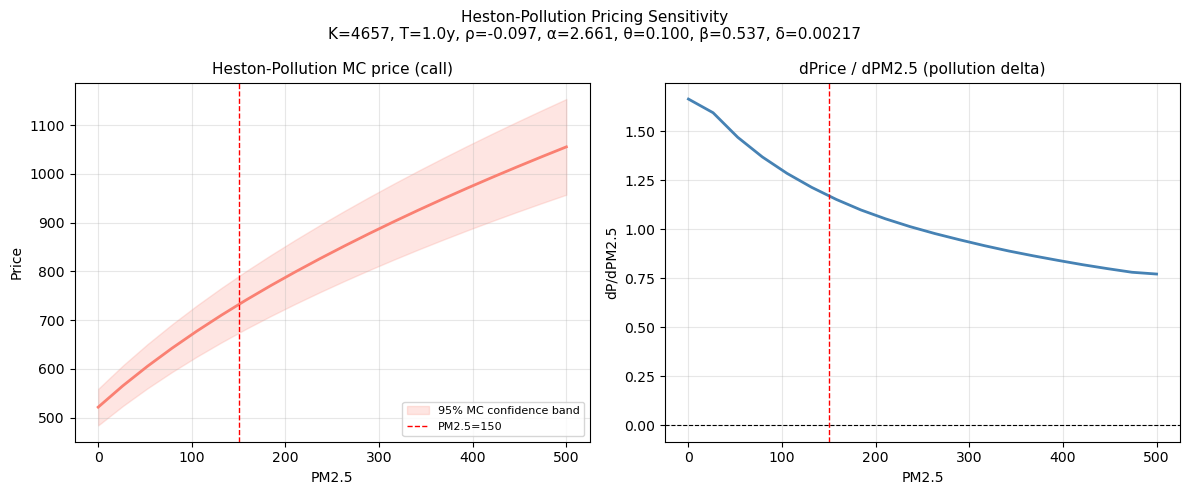

In [ ]:
# Modified Heston pricing model
heston_pol = HestonPollutionPricer(
    sv_model       = sv,
    S0             = df['Close'].iloc[-1],
    returns_series = df['returns'],
    r              = 0.03
)

# Scenario table
strikes = [df['Close'].iloc[-1] * m
           for m in [0.85, 0.90, 0.95, 1.0, 1.05, 1.10, 1.15]]

heston_pol.scenario_table(strikes=strikes, T=1.0, option_type='call')

# Sensitivity plot
heston_pol.plot_sensitivity(
    K           = df['Close'].iloc[-1],
    T           = 1.0,
    pm25_range  = (0, 500),
    n_points    = 20,
    n_paths     = 2000
)

 Strike K  Moneyness Scenario  PM2.5   Heston  Heston+Pol  Premium (Pol)  Premium (%)
  3958.65       0.85      Low     30 962.0191    996.9029        34.8838         3.63
  3958.65       0.85   Medium    100 962.0191   1072.0567       110.0376        11.44
  3958.65       0.85     High    300 962.0191   1254.8439       292.8248        30.44
  4191.52       0.90      Low     30 801.3019    842.8288        41.5269         5.18
  4191.52       0.90   Medium    100 801.3019    930.3185       129.0166        16.10
  4191.52       0.90     High    300 801.3019   1130.9208       329.6189        41.14
  4424.38       0.95      Low     30 658.9601    706.4916        47.5315         7.21
  4424.38       0.95   Medium    100 658.9601    802.8562       143.8962        21.84
  4424.38       0.95     High    300 658.9601   1017.9489       358.9888        54.48
  4657.24       1.00      Low     30 535.5743    586.6158        51.0415         9.53
  4657.24       1.00   Medium    100 535.5743    689.3

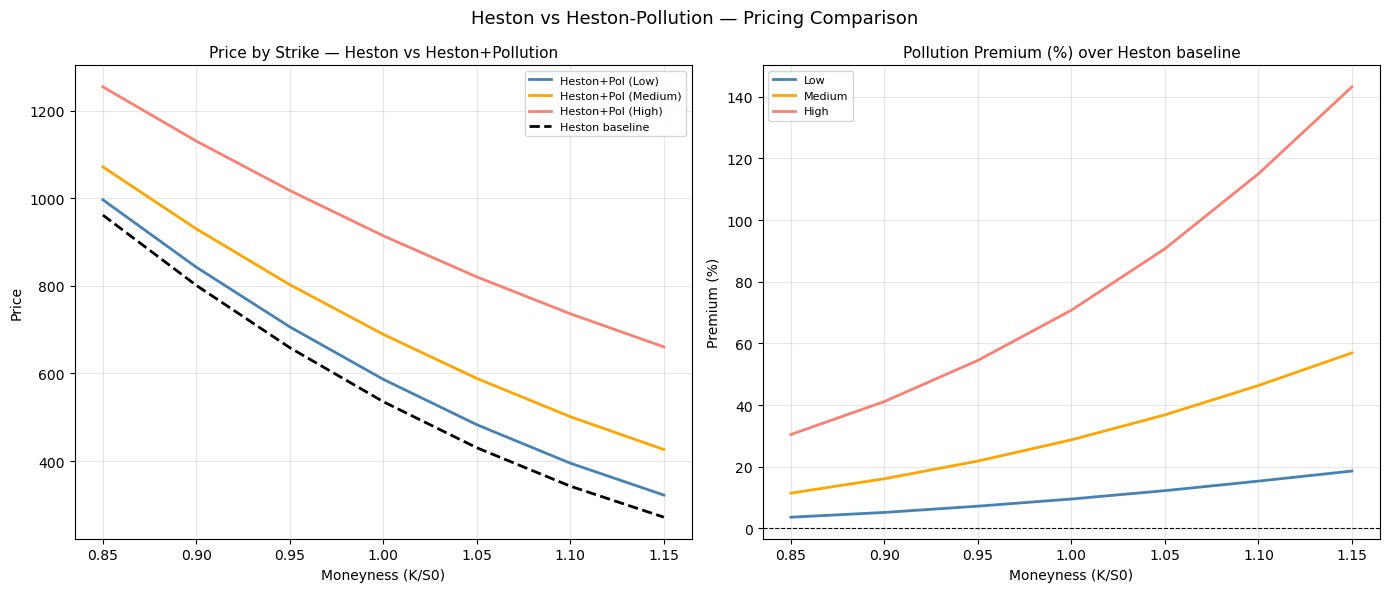

In [8]:
# Heston baseline
heston = HestonPricer(
    sv_model       = sv,
    S0             = df['Close'].iloc[-1],
    returns_series = df['returns'],
    r              = 0.03
)

df_comparison = heston.compare_with_pollution(
    pollution_pricer = heston_pol,
    strikes          = strikes,
    T                = 1.0,
    option_type      = 'call'
)

The Heston-pollution model generates a pollution premium that is both monotonically increasing with out-of-the-money distance and convex in pollution level. Under extreme pollution (PM2.5=300), ATM options are underpriced by 71% and 15%-OTM options by 143% relative to the pollution-free Heston benchmark, highlighting the material cost of ignoring environmental factors in options pricing.